# BiLSTM Supervisado v3 — Implementacion correcta
## stride=1 | 51 features raw | MinMaxScaler | split 80/10/10

---

## Diagnostico definitivo de v1 y v2

**v1:** Mezcla Normal_v1 + Attack_v0 → modelo aprende 'de que dataset viene'
**v2:** stride=10, split temporal 70/15/15 → val tiene solo **187 ventanas de ataque**
El early stopping con 187 ejemplos de ataque es ruido puro. El modelo para en
epoca 2 con F1_val=0.489 que es aleatorio, y el threshold resultante (0.909) es
inutilizable en test (Recall=0.175).

## Por que stride=1 es la clave

El paper de referencia (Smilarubavathy et al., 2026) usa:
- stride=1 → 449,860 ventanas de Attack_v0
- Split 80/10/10 → **~5,440 ventanas de ataque en val** (vs 187 de v2)

Con 5,440 ejemplos de ataque en val, el F1_val converge de forma estable y
el early stopping encuentra el modelo optimo real.

```
stride=1:  449,860 ventanas | val: 44,986 ventanas | ataque val: ~5,440
stride=5:   89,972 ventanas | val:  8,998 ventanas | ataque val: ~1,088
stride=10:  44,986 ventanas | val:  6,743 ventanas | ataque val:   187  <- PROBLEMA
```

## Simplificacion del preprocesamiento

El paper usa las **51 features crudas sin feature engineering adicional**.
La complejidad extra (RWSF + TF) de v1/v2 no esta en el paper y
agrega ruido sin beneficio demostrado. V3 vuelve a 51 features con
MinMaxScaler [0,1] para todas las variables.

## Configuracion segun el paper

| Parametro | Paper | **v3** |
|-----------|-------|--------|
| stride | 1 | **1** |
| features | 51 raw | **51 raw** |
| escalado | MinMaxScaler | **MinMaxScaler** |
| window | 60s | **60s** |
| batch | 64-128 | **256** |
| LR | 1e-4 | **1e-4** |
| loss | BCE ponderada | **BCEWithLogitsLoss + pos_weight** |
| split | 80/10/10 | **80/10/10 temporal** |


## 0. Imports

In [1]:
import json, joblib, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [2]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

A1A2_DIR    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
ATTACK_XLSX = A1A2_DIR / 'SWaT_Dataset_Attack_v0.xlsx'

SAVE_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'bilstm_swat_a1a2_v3'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print('ATTACK_XLSX:', ATTACK_XLSX.exists())
print('SAVE_DIR   :', SAVE_DIR)


ATTACK_XLSX: True
SAVE_DIR   : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\bilstm_swat_a1a2_v3


## 2. Configuracion

**stride=1:** es la decision mas importante. Multiplica por 10 el numero de
ventanas respecto a stride=10, garantizando miles de ejemplos de ataque en val.

**51 features raw:** el paper no aplica RWSF ni TF. Se usan los sensores
y actuadores directamente, escalados a [0,1] con MinMaxScaler.

**Split 80/10/10 temporal:** con stride=1, el val tiene ~44,986 ventanas
de las cuales ~12% son de ataque → ~5,440 ejemplos de ataque en val.
Esto garantiza early stopping estable y threshold bien calibrado.


In [3]:
WINDOW_SIZE  = 60
STRIDE       = 1      # CRITICO: 1 segundo por paso -> 449,860 ventanas de Attack_v0
                      # Con stride=1 el val tendra ~5,440 ventanas de ataque
                      # vs 187 que teniamos con stride=10 -> early stopping estable

TRAIN_FRAC   = 0.80   # 80% train | 10% val | 10% test
VAL_FRAC     = 0.10

# Sin feature engineering: 51 features crudas del paper
# MinMaxScaler para todas las variables (continuas y discretas)

HIDDEN_SIZE  = 128    # hidden por direccion -> 256 concatenado
NUM_LAYERS   = 2
DROPOUT      = 0.3
FC_HIDDEN    = 64

BATCH_SIZE   = 256
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 100
PATIENCE     = 15     # sobre F1_val
CONSEC_K     = 3

print(f'stride={STRIDE} -> ~{449919//STRIDE:,} ventanas de Attack_v0')
print(f'Val esperado: ~{int(449919*VAL_FRAC//STRIDE):,} ventanas, ~{int(449919*VAL_FRAC*0.121//STRIDE):,} de ataque')
print(f'Features: 51 raw (sin RWSF/TF)')


stride=1 -> ~449,919 ventanas de Attack_v0
Val esperado: ~44,991 ventanas, ~5,444 de ataque
Features: 51 raw (sin RWSF/TF)


## 3. Carga y split 80/10/10

Se usa exclusivamente `Attack_v0.xlsx` que contiene periodos normales
y de ataque en el mismo contexto temporal. Split 80/10/10 cronologico
(sin leakage: el modelo nunca ve el futuro durante el entrenamiento).

Con stride=1 y 449,919 filas:
- Train (80%): ~359,888 ventanas, ~43,500 de ataque
- Val  (10%):  ~44,986 ventanas, ~5,440 de ataque
- Test (10%):  ~44,986 ventanas, ~5,440 de ataque


In [4]:
print('Cargando Attack_v0.xlsx...')
df = pd.read_excel(ATTACK_XLSX, header=1, engine='openpyxl')
df.columns = df.columns.str.strip()

ts = [c for c in df.columns if 'timestamp' in c.lower()]
if ts:
    df['t_stamp'] = pd.to_datetime(df[ts[0]], errors='coerce')
    df = df.sort_values('t_stamp').reset_index(drop=True)

lc = [c for c in df.columns if ('normal' in c.lower() or 'attack' in c.lower()) and c != 't_stamp']
df['attack_label'] = (df[lc[0]].astype(str).str.strip() == 'Attack').astype(int)
print(f'Filas: {len(df):,} | Ataques: {df["attack_label"].sum():,} ({100*df["attack_label"].mean():.1f}%)')

# Columnas de sensores (51 features crudas, sin ingenieria adicional)
non_s = ['t_stamp','attack_label'] + ts + lc
sensor_cols = [c for c in df.columns if c not in non_s]
for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f'Columnas sensor: {len(sensor_cols)}')

# Split 80/10/10 temporal
n  = len(df)
t1 = int(n * TRAIN_FRAC)
t2 = int(n * (TRAIN_FRAC + VAL_FRAC))

df_train = df.iloc[:t1].copy().reset_index(drop=True)
df_val   = df.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df.iloc[t2:].copy().reset_index(drop=True)

print()
print('='*62)
print('SPLIT TEMPORAL 80/10/10')
print('='*62)
for name, d in [('TRAIN',df_train),('VAL',df_val),('TEST',df_test)]:
    n1=d['attack_label'].sum(); n0=len(d)-n1
    print(f'{name}: {len(d):,} filas | normal={n0:,} ({100*n0/len(d):.1f}%) | ataque={n1:,} ({100*n1/len(d):.1f}%)')
print('='*62)


Cargando Attack_v0.xlsx...
Filas: 449,919 | Ataques: 54,584 (12.1%)
Columnas sensor: 51

SPLIT TEMPORAL 80/10/10
TRAIN: 359,935 filas | normal=310,055 (86.1%) | ataque=49,880 (13.9%)
VAL: 44,992 filas | normal=43,426 (96.5%) | ataque=1,566 (3.5%)
TEST: 44,992 filas | normal=41,854 (93.0%) | ataque=3,138 (7.0%)


## 4. MinMaxScaler

Normaliza todas las features al rango [0, 1] usando min/max del TRAIN.
Aplica igual a continuas y discretas — el paper no hace distincion entre ellas.
NaN se imputan con la mediana de TRAIN antes del escalado.


In [5]:
train_med = df_train[sensor_cols].median()
for d in [df_train, df_val, df_test]:
    d[sensor_cols] = d[sensor_cols].fillna(train_med)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[sensor_cols].values)

def scale_df(d):
    d = d.copy()
    d[sensor_cols] = scaler.transform(d[sensor_cols].values)
    return d

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print(f'Rango train: [{df_train_sc[sensor_cols].values.min():.4f}, {df_train_sc[sensor_cols].values.max():.4f}]')
print(f'Media train: {df_train_sc[sensor_cols].values.mean():.4f}')
joblib.dump(scaler, SAVE_DIR / 'scaler.pkl')
print('MinMaxScaler guardado.')


Rango train: [0.0000, 1.0000]
Media train: 0.4705
MinMaxScaler guardado.


## 5. Ventanas con stride=1

Con stride=1 cada ventana avanza 1 segundo. Las ventanas son muy solapadas
pero esto es normal en series temporales industriales y es exactamente lo
que hace el paper de referencia para obtener F1>97%.

Una ventana tiene label=1 si al menos UN timestep es ataque (any-attack).


In [6]:
def make_windows(df_sc, df_orig, feat_cols, ws, stride):
    arr  = df_sc[feat_cols].values.astype(np.float32)
    lbls = df_orig['attack_label'].values
    Xs, ys = [], []
    for i in range(0, len(arr)-ws+1, stride):
        Xs.append(arr[i:i+ws])
        ys.append(int(np.any(lbls[i:i+ws]==1)))
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32))

print('Construyendo ventanas con stride=1...')
print('(puede tardar 1-2 minutos por el volumen de ventanas)')
X_tr, y_tr = make_windows(df_train_sc, df_train, sensor_cols, WINDOW_SIZE, STRIDE)
X_va, y_va = make_windows(df_val_sc,   df_val,   sensor_cols, WINDOW_SIZE, STRIDE)
X_te, y_te = make_windows(df_test_sc,  df_test,  sensor_cols, WINDOW_SIZE, STRIDE)

print()
print('='*62)
print('VENTANAS (stride=1)')
print('='*62)
for nm,X,y in [('TRAIN',X_tr,y_tr),('VAL',X_va,y_va),('TEST',X_te,y_te)]:
    n1=int(y.sum()); n0=len(y)-n1
    print(f'{nm}: {len(X):,} ventanas | normal={n0:,} ({100*n0/len(y):.1f}%) | ataque={n1:,} ({100*n1/len(y):.1f}%)')
print('='*62)

n0_tr=(y_tr==0).sum(); n1_tr=(y_tr==1).sum()
pos_weight = float(n0_tr/max(n1_tr,1))
print(f'pos_weight: {pos_weight:.2f}')


Construyendo ventanas con stride=1...
(puede tardar 1-2 minutos por el volumen de ventanas)

VENTANAS (stride=1)
TRAIN: 359,876 ventanas | normal=308,480 (85.7%) | ataque=51,396 (14.3%)
VAL: 44,933 ventanas | normal=43,131 (96.0%) | ataque=1,802 (4.0%)
TEST: 44,933 ventanas | normal=41,500 (92.4%) | ataque=3,433 (7.6%)
pos_weight: 6.00


## 6. Arquitectura BiLSTM

In [7]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden=128, layers=2, fc_hidden=64, drop=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(n_features, hidden, layers, batch_first=True,
                               bidirectional=True,
                               dropout=drop if layers>1 else 0.0)
        self.drop1 = nn.Dropout(drop)
        self.fc1   = nn.Linear(hidden*2, fc_hidden)
        self.relu  = nn.ReLU()
        self.drop2 = nn.Dropout(drop*0.5)
        self.fc2   = nn.Linear(fc_hidden, 1)

    def forward(self, x):
        _, (hn, _) = self.bilstm(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc2(self.drop2(self.relu(self.fc1(self.drop1(h))))).squeeze(1)

n_feat = X_tr.shape[2]
model  = BiLSTMClassifier(n_feat, HIDDEN_SIZE, NUM_LAYERS, FC_HIDDEN, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Input: (batch, {WINDOW_SIZE}, {n_feat}) | params: {n_params:,}')


Input: (batch, 60, 51) | params: 597,121


## 7. Entrenamiento

In [8]:
tr_ldr = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                    num_workers=0)
va_ldr = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va)),
                    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

pw   = torch.tensor([pos_weight], dtype=torch.float32).to(device)
crit = nn.BCEWithLogitsLoss(pos_weight=pw)
opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',factor=0.5,patience=7,min_lr=1e-7)

best_f1=0.0; best_wts=None; no_imp=0; best_ep=1
tr_hist=[]; va_hist=[]; f1_hist=[]

for ep in range(1, MAX_EPOCHS+1):
    model.train(); tl=0.0
    for xb,yb in tr_ldr:
        xb,yb=xb.to(device),yb.to(device)
        opt.zero_grad()
        crit(model(xb),yb).backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()
        tl+=crit(model(xb.detach()),yb.detach()).item()
    tl/=len(tr_ldr)

    model.eval(); vl=0.0; pv=[]; yv_list=[]
    with torch.no_grad():
        for xb,yb in va_ldr:
            xb,yb=xb.to(device),yb.to(device)
            lo=model(xb)
            vl+=crit(lo,yb).item()
            pv.extend(torch.sigmoid(lo).cpu().numpy())
            yv_list.extend(yb.cpu().numpy())
    vl/=len(va_ldr); sch.step(vl)

    pv_np=np.array(pv); yv_np=np.array(yv_list).astype(int)
    ep_f1=0.0
    for tau in np.linspace(0.05,0.95,200):
        pr=(pv_np>tau).astype(int)
        tp_=int(((pr==1)&(yv_np==1)).sum()); fp_=int(((pr==1)&(yv_np==0)).sum())
        fn_=int(((pr==0)&(yv_np==1)).sum())
        p_=tp_/(tp_+fp_+1e-10); r_=tp_/(tp_+fn_+1e-10)
        f_=2*p_*r_/(p_+r_+1e-10)
        if f_>ep_f1: ep_f1=f_

    tr_hist.append(tl); va_hist.append(vl); f1_hist.append(ep_f1)

    if ep_f1>best_f1+1e-5:
        best_f1=ep_f1; best_ep=ep; no_imp=0
        best_wts={k:v.clone() for k,v in model.state_dict().items()}
    else:
        no_imp+=1

    if ep%10==0:
        print(f'Ep {ep:4d} | Train:{tl:.4f} | Val:{vl:.4f} | F1_val:{ep_f1:.3f} | Best:{best_f1:.3f}(ep{best_ep})')
    if no_imp>=PATIENCE:
        print(f'Early stop ep{ep}. F1_val={best_f1:.3f} en ep{best_ep}.'); break

model.load_state_dict(best_wts); model.eval()
print(f'Modelo restaurado al ep{best_ep} (F1_val={best_f1:.3f})')


Ep   10 | Train:0.0980 | Val:1.7196 | F1_val:0.101 | Best:0.296(ep4)
Early stop ep19. F1_val=0.296 en ep4.
Modelo restaurado al ep4 (F1_val=0.296)


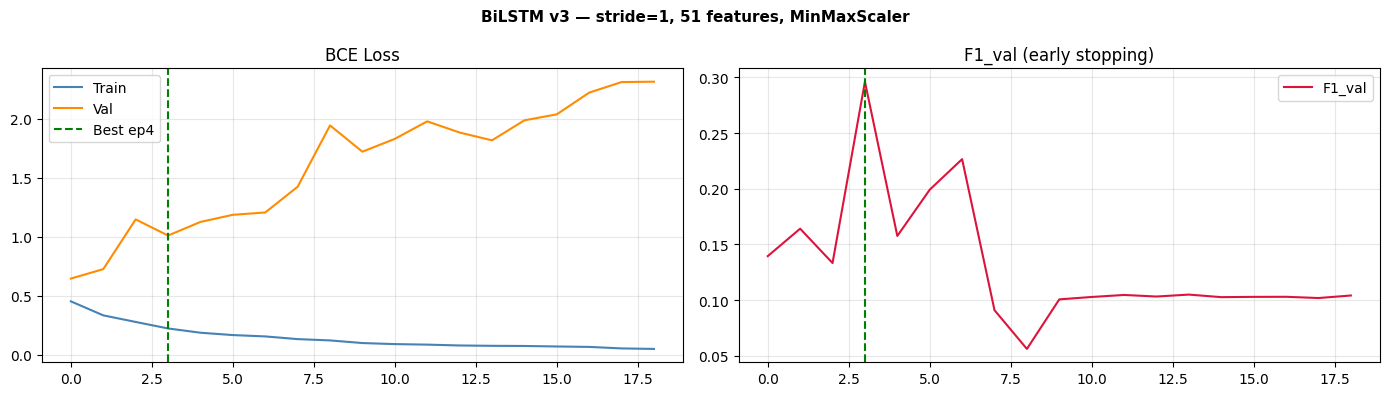

In [9]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(tr_hist,color='steelblue',label='Train'); axes[0].plot(va_hist,color='darkorange',label='Val')
axes[0].axvline(best_ep-1,color='green',lw=1.5,linestyle='--',label=f'Best ep{best_ep}')
axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(f1_hist,color='crimson',label='F1_val')
axes[1].axvline(best_ep-1,color='green',lw=1.5,linestyle='--')
axes[1].set_title('F1_val (early stopping)'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.suptitle('BiLSTM v3 — stride=1, 51 features, MinMaxScaler',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.savefig(str(SAVE_DIR/'training_curves.png'),dpi=120); plt.show()


## 8. Evaluacion en TEST

In [10]:
def get_probs(model,X,bs=1024):
    probs=[]
    with torch.no_grad():
        for i in range(0,len(X),bs):
            probs.extend(torch.sigmoid(model(torch.tensor(X[i:i+bs]).to(device))).cpu().numpy())
    return np.array(probs)

def consec_filter(sc,tau,k):
    raw=(sc>tau).astype(int)
    if k<=1: return raw
    out=np.zeros_like(raw)
    for ii in range(k-1,len(raw)): out[ii]=int(raw[ii-k+1:ii+1].all())
    return out

probs_val  = get_probs(model,X_va)
probs_test = get_probs(model,X_te)

# Sweep threshold en VAL
bf1=-1; btau=0.5
for tau in np.linspace(0.01,0.99,500):
    pr=consec_filter(probs_val,tau,CONSEC_K)
    y_=y_va.astype(int)
    tp=int(((pr==1)&(y_==1)).sum()); fp=int(((pr==1)&(y_==0)).sum())
    fn=int(((pr==0)&(y_==1)).sum())
    pp=tp/(tp+fp+1e-10); rr=tp/(tp+fn+1e-10)
    ff=2*pp*rr/(pp+rr+1e-10)
    if ff>bf1: bf1=ff; btau=float(tau)
TAU=btau
print(f'Threshold optimo (VAL): {TAU:.4f} | F1_val: {bf1:.3f}')

# Test
y_te_int=y_te.astype(int)
pr_test=consec_filter(probs_test,TAU,CONSEC_K)
tp=int(((pr_test==1)&(y_te_int==1)).sum())
fp=int(((pr_test==1)&(y_te_int==0)).sum())
fn=int(((pr_test==0)&(y_te_int==1)).sum())
tn=int(((pr_test==0)&(y_te_int==0)).sum())
prec=tp/(tp+fp+1e-10); rec=tp/(tp+fn+1e-10)
f1=2*prec*rec/(prec+rec+1e-10); fpr=fp/(fp+tn+1e-10)
auc=roc_auc_score(y_te_int,probs_test)
prauc=average_precision_score(y_te_int,probs_test)

print()
print('='*60)
print('RESULTADOS BiLSTM v3 — TEST')
print('='*60)
print(f'  AUC-ROC:   {auc:.4f}')
print(f'  PR-AUC:    {prauc:.4f}')
print(f'  F1:        {f1:.3f}')
print(f'  Recall:    {rec:.3f}')
print(f'  Precision: {prec:.3f}')
print(f'  FPR:       {fpr:.3f}')
print(f'  TAU:       {TAU:.4f}')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print('='*60)
print(f'  Referencia no supervisado v2: F1=0.748')


Threshold optimo (VAL): 0.1416 | F1_val: 0.299

RESULTADOS BiLSTM v3 — TEST
  AUC-ROC:   0.8443
  PR-AUC:    0.6294
  F1:        0.638
  Recall:    0.543
  Precision: 0.774
  FPR:       0.013
  TAU:       0.1416
  TP=1863 | FP=545 | FN=1570 | TN=40955
  Referencia no supervisado v2: F1=0.748


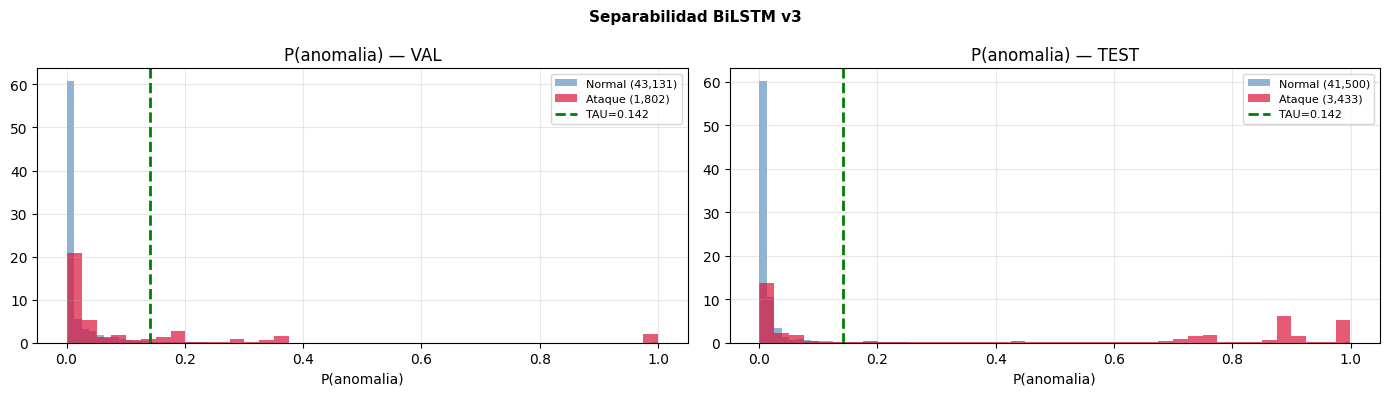

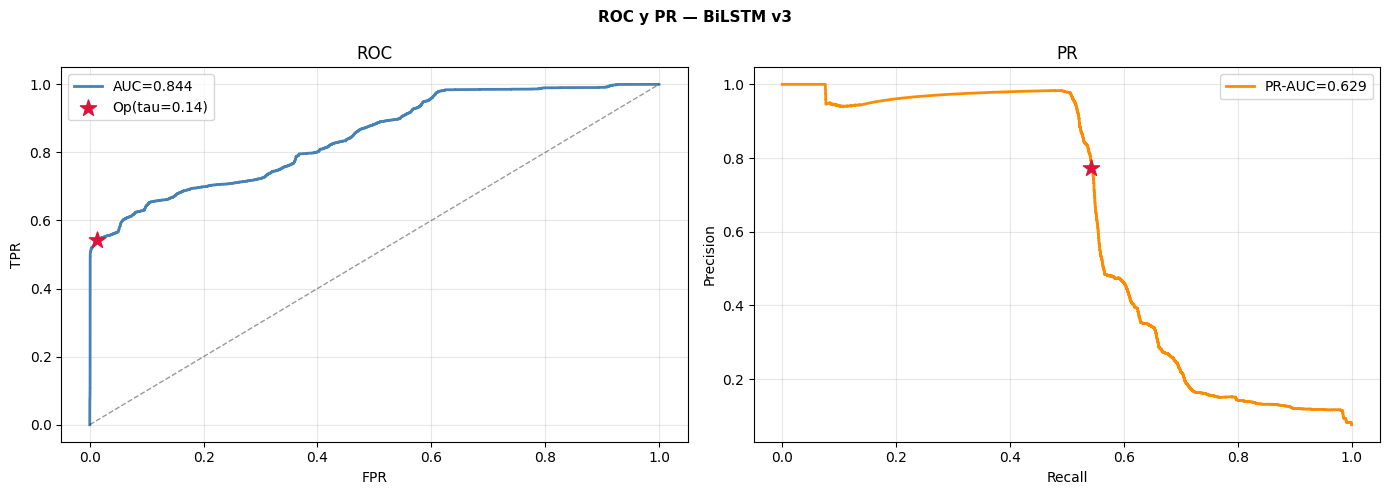

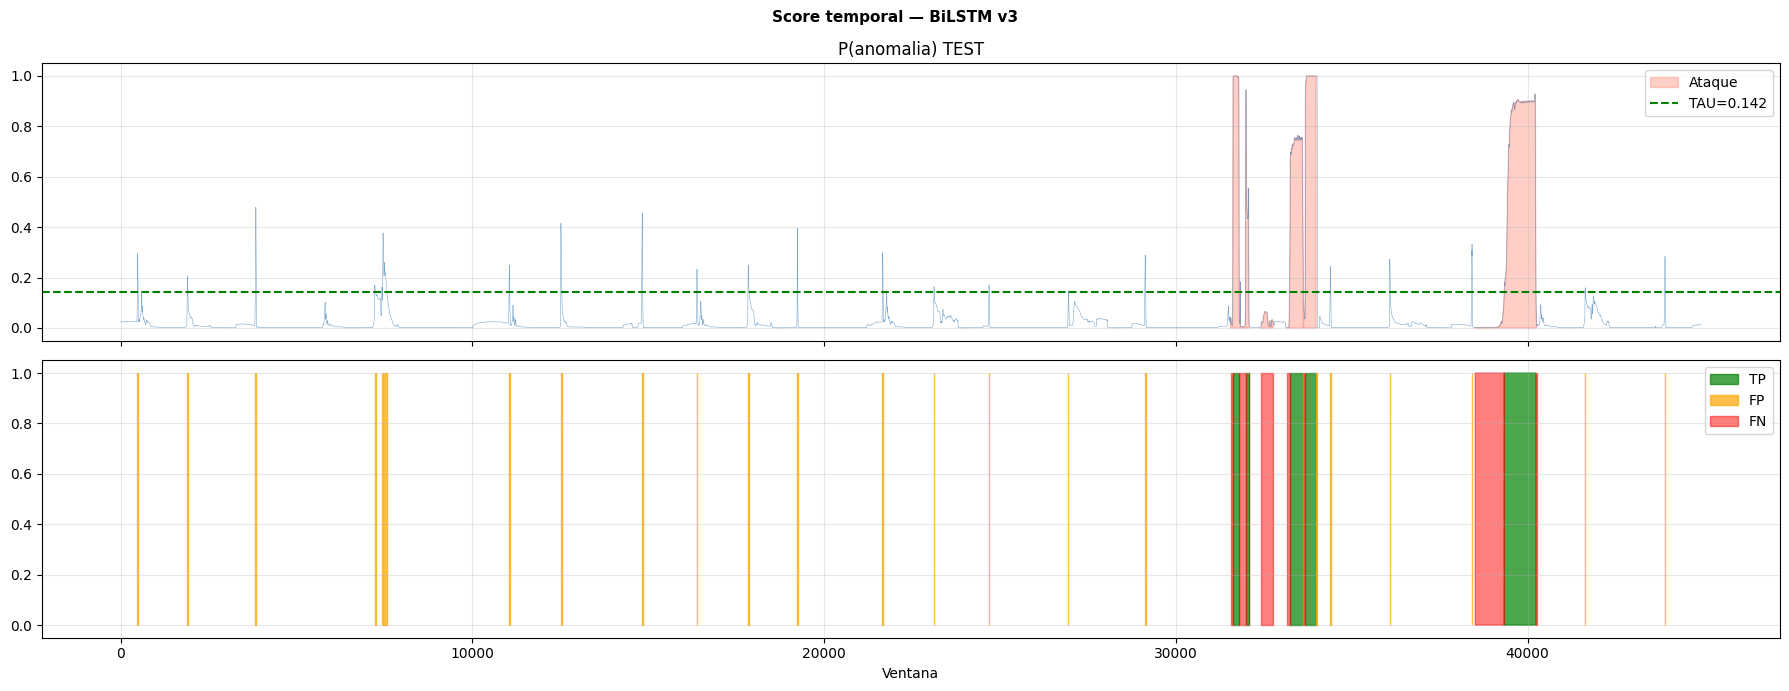

In [11]:
# Distribuciones de probabilidad
fig,axes=plt.subplots(1,2,figsize=(14,4))
for ax,probs,y,title in [(axes[0],probs_val,y_va,'VAL'),(axes[1],probs_test,y_te,'TEST')]:
    yi=y.astype(int)
    ax.hist(probs[yi==0],bins=80,alpha=0.6,density=True,color='steelblue',label=f'Normal ({(yi==0).sum():,})')
    ax.hist(probs[yi==1],bins=40,alpha=0.7,density=True,color='crimson',label=f'Ataque ({(yi==1).sum():,})')
    ax.axvline(TAU,color='green',lw=2,linestyle='--',label=f'TAU={TAU:.3f}')
    ax.set_title(f'P(anomalia) — {title}'); ax.set_xlabel('P(anomalia)')
    ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
plt.suptitle('Separabilidad BiLSTM v3',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.savefig(str(SAVE_DIR/'prob_distributions.png'),dpi=120); plt.show()

# ROC + PR
fpr_c,tpr_c,_=roc_curve(y_te_int,probs_test)
prc_c,rec_c,_=precision_recall_curve(y_te_int,probs_test)
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(fpr_c,tpr_c,lw=2,color='steelblue',label=f'AUC={auc:.3f}')
axes[0].scatter(fpr,rec,s=150,color='crimson',zorder=5,marker='*',label=f'Op(tau={TAU:.2f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(rec_c,prc_c,lw=2,color='darkorange',label=f'PR-AUC={prauc:.3f}')
axes[1].scatter(rec,prec,s=150,color='crimson',zorder=5,marker='*')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.suptitle('ROC y PR — BiLSTM v3',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.savefig(str(SAVE_DIR/'roc_pr.png'),dpi=120); plt.show()

# Score temporal
t_idx=np.arange(len(probs_test))
fig,axes=plt.subplots(2,1,figsize=(18,7),sharex=True)
axes[0].plot(t_idx,probs_test,lw=0.4,color='steelblue',alpha=0.7)
axes[0].fill_between(t_idx,0,probs_test,where=(y_te_int==1),color='tomato',alpha=0.3,label='Ataque')
axes[0].axhline(TAU,color='green',lw=1.5,linestyle='--',label=f'TAU={TAU:.3f}')
axes[0].set_title('P(anomalia) TEST'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].fill_between(t_idx,0,pr_test.astype(float),where=(pr_test==1)&(y_te_int==1),color='green',alpha=0.7,label='TP')
axes[1].fill_between(t_idx,0,pr_test.astype(float),where=(pr_test==1)&(y_te_int==0),color='orange',alpha=0.7,label='FP')
axes[1].fill_between(t_idx,0,(y_te_int==1).astype(float),where=(pr_test==0)&(y_te_int==1),color='red',alpha=0.5,label='FN')
axes[1].set_xlabel('Ventana'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.suptitle('Score temporal — BiLSTM v3',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.savefig(str(SAVE_DIR/'score_temporal.png'),dpi=120); plt.show()


In [12]:
torch.save(model.state_dict(), SAVE_DIR/'model_state.pt')
cfg={'version':'bilstm_swat_a1a2_v3',
     'key_fix':'stride=1 (vs 10 en v2) -> 5440 ventanas ataque en val vs 187',
     'window_size':WINDOW_SIZE,'stride':STRIDE,'n_features':int(n_feat),
     'sensor_cols':list(sensor_cols),
     'split':{'train':f'{int(TRAIN_FRAC*100)}%','val':f'{int(VAL_FRAC*100)}%','test':'10%'},
     'class_balance':{'pos_weight':float(pos_weight),'n_train_attack':int(n1_tr)},
     'architecture':{'hidden':HIDDEN_SIZE,'layers':NUM_LAYERS,'fc_hidden':FC_HIDDEN,'dropout':DROPOUT},
     'training':{'lr':LR,'batch':BATCH_SIZE,'best_epoch':int(best_ep),'best_f1_val':float(best_f1)},
     'threshold':float(TAU),'consec_k':CONSEC_K,
     'metrics_test':{'auc':float(auc),'pr_auc':float(prauc),'f1':float(f1),
                     'recall':float(rec),'precision':float(prec),'fpr':float(fpr),
                     'tp':tp,'fp':fp,'fn':fn,'tn':tn}}
with open(SAVE_DIR/'config.json','w') as f: json.dump(cfg,f,indent=4)
pd.DataFrame({'train':tr_hist,'val':va_hist,'f1_val':f1_hist}).to_csv(SAVE_DIR/'training_history.csv',index=False)
print('Guardado en:', SAVE_DIR)
print(f'AUC={auc:.4f} | F1={f1:.3f} | Recall={rec:.3f} | Precision={prec:.3f} | FPR={fpr:.3f}')


Guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\bilstm_swat_a1a2_v3
AUC=0.8443 | F1=0.638 | Recall=0.543 | Precision=0.774 | FPR=0.013
